# Age Group Classifier - Deployment Demo (v7)

**Model:** MobileNetV2 + augmentation + LR-decay schedule (`v7`)
**Test accuracy:** 53.93% exact band, 89.87% one-off (within one band)

---

### Model selection note

v7 is the **highest-accuracy** model in the experiment series. It is demoed here
as the performance-maximising configuration.

For completeness, the accompanying analysis notebook selects **v4** as the
*deployed* model on fairness grounds: v7 has a wider race gap (17.91pp vs 11.29pp)
and a lower disparate-impact ratio (73.4% vs 80.5%). The two models differ in
accuracy by 4.39pp, which is within the measured +/-3.4pp initialisation noise
floor. This demo therefore shows v7's raw capability; deployment trade-offs are
documented in the model card.


## 1. Load the model

In [1]:
import numpy as np
import tensorflow as tf
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

DATA       = Path("/home/jovyan/vault/face_project/data")
MODEL_PATH = DATA / "age_classifier_mobilenetv2_224_recipe2.keras"   # v7

AGE_BANDS = ["0-2", "3-9", "10-19", "20-29", "30-39",
             "40-49", "50-59", "60-69", "70+"]

model = tf.keras.models.load_model(MODEL_PATH, compile=False)
print(f"Loaded v7  |  input {model.input_shape}  |  {model.count_params():,} params")

# v7 (Recipe B) has a Rescaling layer BUILT IN and expects raw [0,255] input.
# (v4, by contrast, was trained on [0,1] — do not reuse v4 preprocessing here.)
INPUT_RANGE = "0-255"

2026-07-20 21:14:19.632158: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
2026-07-20 21:14:19.633347: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.


Loaded v7  |  input (None, 224, 224, 3)  |  2,589,001 params


## 2. Prediction function

Loads a face image, runs the model, returns the top age band with its
confidence and the top-3 distribution. Two honesty guards are wired in:

- **Middle-age warning** — bands 30-59 have < 40% per-class recall (see confusion
  matrix in the analysis notebook), so the model routinely confuses adjacent
  decades there.
- **Low-confidence warning** — flags predictions the model itself is unsure about.


In [2]:
LOW_RELIABILITY = {"30-39", "40-49", "50-59"}   # recall < 0.40 in the audit

def preprocess(img_path):
    img = Image.open(img_path).convert("RGB").resize((224, 224), Image.BILINEAR)
    return np.asarray(img, np.float32)[None]          # [0,255], no division

def predict_age(img_path, show=True, top_k=3):
    x     = preprocess(img_path)
    probs = model.predict(x, verbose=0)[0]
    order = np.argsort(probs)[::-1]
    top   = order[0]
    band  = AGE_BANDS[top]
    conf  = probs[top]

    print(f"Prediction : {band}   (confidence {conf:.0%})")
    print("Top-3:")
    for i in order[:top_k]:
        print(f"   {AGE_BANDS[i]:<7} {probs[i]:.0%}")

    if band in LOW_RELIABILITY:
        print(f"\n  [!] '{band}' is in the model's low-reliability range (ages 30-59, "
              f"recall < 40%).\n      Middle-age bands are frequently confused with "
              f"neighbours - treat as approximate.")
    if conf < 0.45:
        print(f"\n  [!] Low confidence ({conf:.0%}) - the model is uncertain.")

    if show:
        img = Image.open(img_path).convert("RGB")
        plt.figure(figsize=(3.2, 3.6))
        plt.imshow(img); plt.axis("off")
        plt.title(f"{band}  ({conf:.0%})", fontsize=11)
        plt.show()
    return band, probs


## 3. Single-image demo

Point it at any face image.

In [4]:
import pandas as pd
from pathlib import Path

DATA = Path("/home/jovyan/vault/face_project/data")
test_df = pd.read_csv(DATA / "test_df.csv")

# real image folder (confirmed: nested UTKFace/UTKFace)
UTK = DATA / "UTKFace" / "UTKFace"
assert UTK.exists() and any(UTK.glob("*.jpg")), f"no images in {UTK}"

# remap stale filepaths -> filename under the real folder
test_df["filepath"] = test_df["filepath"].apply(lambda p: str(UTK / Path(p).name))

ok = sum(Path(p).exists() for p in test_df["filepath"].head(20))
print(f"images: {UTK}")
print(f"{ok}/20 sample paths resolve")
assert ok == 20, "still broken"

images: /home/jovyan/vault/face_project/data/UTKFace/UTKFace
20/20 sample paths resolve


## 4. Batch gallery

Runs the model on a grid of random test faces, green title = correct band, red = wrong.

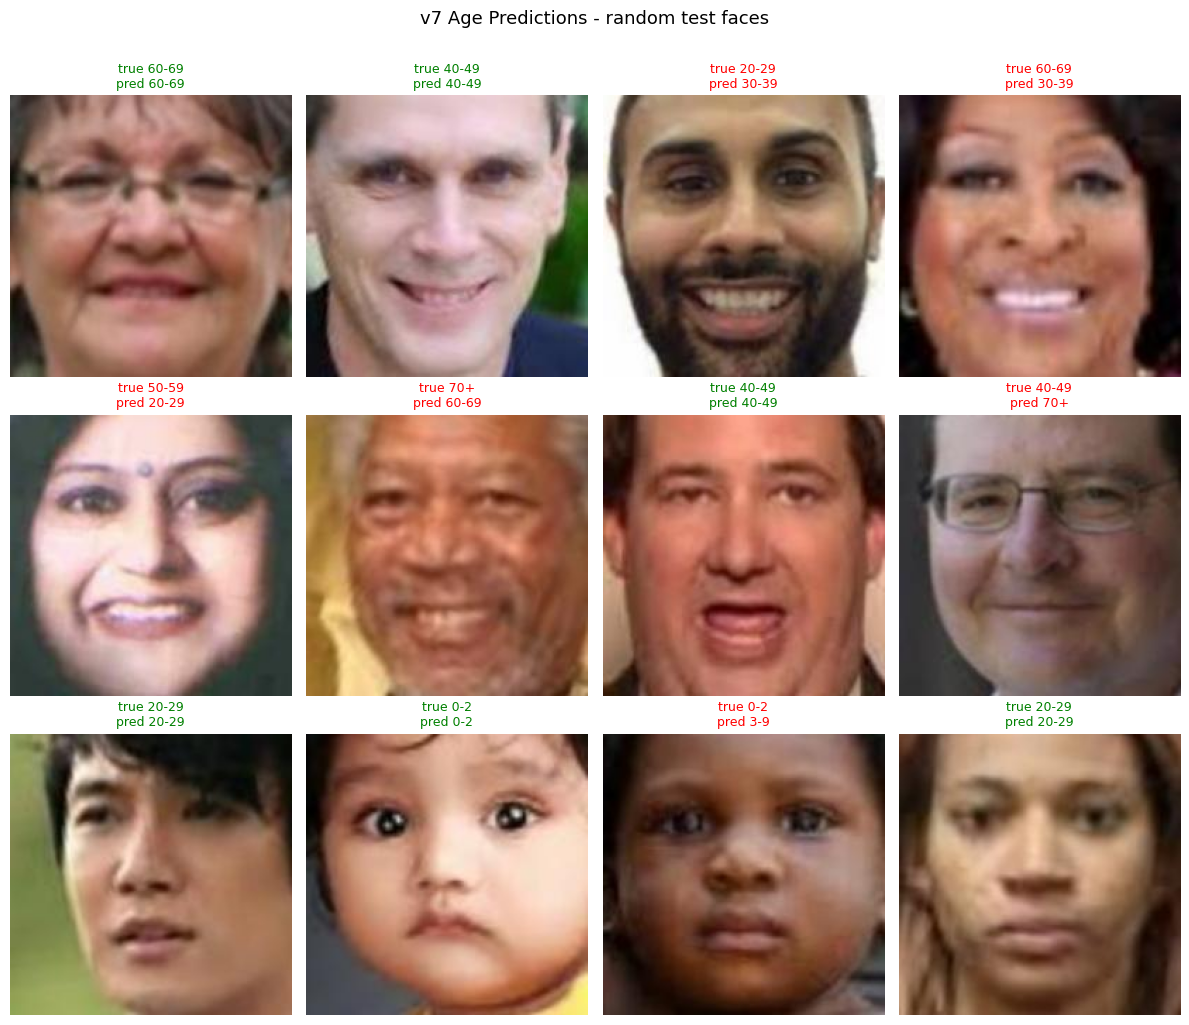

In [5]:
N = 12
picks = test_df.sample(N, random_state=1).reset_index(drop=True)

cols = 4
rows = int(np.ceil(N / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3.0*cols, 3.4*rows))
axes = np.array(axes).reshape(-1)

for ax, (_, r) in zip(axes, picks.iterrows()):
    x     = preprocess(r["filepath"])
    probs = model.predict(x, verbose=0)[0]
    pred  = AGE_BANDS[int(np.argmax(probs))]
    ok    = (pred == r["age_group"])
    ax.imshow(Image.open(r["filepath"]).convert("RGB"))
    ax.axis("off")
    ax.set_title(f"true {r['age_group']}\npred {pred}",
                 color="green" if ok else "red", fontsize=9)
for ax in axes[N:]:
    ax.axis("off")

plt.suptitle("v7 Age Predictions - random test faces", y=1.01, fontsize=13)
plt.tight_layout(); plt.show()


## 5. Honesty check - per-race accuracy on this demo run

A demo that only shows cherry-picked correct predictions is misleading. This cell
reports v7's accuracy broken down by race on the full test set, so the demo
carries the same fairness context as the analysis.


In [6]:
y_true = test_df["label"].values

if "X_TE224" in globals() and len(X_TE224) == len(test_df):
    X = X_TE224.astype(np.float32)          # already 224px, already [0,255]
    print("using X_TE224 from memory (fast path)")
else:
    X = np.stack([np.asarray(Image.open(p).convert("RGB")
                             .resize((224, 224), Image.BILINEAR), np.float32)
                  for p in test_df["filepath"]])           # [0,255]
    print("rebuilt 224px test images from disk")

y_pred = np.argmax(model.predict(X, batch_size=64, verbose=0), axis=1)

df = test_df.copy()
df["correct"] = (y_true == y_pred)
per = df.groupby("race")["correct"].agg(["mean", "size"]).sort_values("mean")

print("v7 accuracy by race (full test set):\n")
for race, row in per.iterrows():
    print(f"   {race:<8} {row['mean']:.1%}   (n={int(row['size'])})")

gap   = per["mean"].max() - per["mean"].min()
ratio = per["mean"].min() / per["mean"].max()
print(f"\n   overall      {df['correct'].mean():.1%}")
print(f"   race gap     {gap*100:.2f}pp   (best {per['mean'].idxmax()}, "
      f"worst {per['mean'].idxmin()})")
print(f"   ratio        {ratio:.1%}")
print("\n   Note: v7's race gap (~18pp) is the reason the analysis notebook deploys")
print("   v4 instead. This demo shows v7's raw accuracy, not the deployment choice.")


rebuilt 224px test images from disk
v7 accuracy by race (full test set):

   White    49.5%   (n=1550)
   Black    50.3%   (n=682)
   Indian   56.2%   (n=575)
   Other    59.6%   (n=240)
   Asian    67.4%   (n=506)

   overall      54.0%
   race gap     17.91pp   (best Asian, worst White)
   ratio        73.4%

   Note: v7's race gap (~18pp) is the reason the analysis notebook deploys
   v4 instead. This demo shows v7's raw accuracy, not the deployment choice.


In [7]:
!pip install gradio -q

import gradio as gr, numpy as np, tensorflow as tf
from pathlib import Path
from PIL import Image

DATA = Path("/home/jovyan/vault/face_project/data")
model = tf.keras.models.load_model(
    DATA / "age_classifier_mobilenetv2_224_recipe2.keras", compile=False)

BANDS = ["0-2","3-9","10-19","20-29","30-39","40-49","50-59","60-69","70+"]
LOW   = {"30-39","40-49","50-59"}

def _needs_raw(m):                       # v7 has Rescaling baked in -> [0,255]
    for l in m.layers:
        if isinstance(l, tf.keras.layers.Rescaling): return True
        if isinstance(l, tf.keras.Model) and _needs_raw(l): return True
    return False
RAW = _needs_raw(model)
print("input range:", "[0,255]" if RAW else "[0,1]")

def classify(img):
    if img is None:
        return {}, ""
    x = np.asarray(img.convert("RGB").resize((224,224)), np.float32)[None]
    if not RAW: x /= 255.0
    p = model.predict(x, verbose=0)[0]
    conf = {BANDS[i]: float(p[i]) for i in range(9)}        # all bands + top
    top  = BANDS[int(np.argmax(p))]
    note = ""
    if top in LOW:
        note = f"⚠ '{top}' is in the low-reliability range (ages 30–59, recall < 40%). Approximate."
    if float(p.max()) < 0.45:
        note += f"\n⚠ Low confidence ({p.max():.0%})."
    return conf, note

demo = gr.Interface(
    fn=classify,
    inputs=gr.Image(type="pil", sources=["upload","webcam"],
                    label="Upload or capture a face"),
    outputs=[gr.Label(num_top_classes=9, label="Age band confidence"),
             gr.Textbox(label="Notes")],
    title="Age Group Classifier (v7)",
    description="Upload a photo or use your webcam. Shows the predicted band and "
                "confidence across all 9 age groups.",
    flagging_mode="never",
)
demo.launch(share=True)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tokenizers 0.20.1 requires huggingface-hub<1.0,>=0.16.4, but you have huggingface-hub 1.24.0 which is incompatible.
transformers 4.45.2 requires huggingface-hub<1.0,>=0.23.2, but you have huggingface-hub 1.24.0 which is incompatible.

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


ModuleNotFoundError: No module named 'gradio'

In [8]:
import sys
!{sys.executable} -m pip install "gradio==4.44.1" --no-deps
!{sys.executable} -m pip install fastapi uvicorn "python-multipart" aiofiles \
    "huggingface-hub>=0.19" pydub ffmpy tomlkit "typer>=0.12" \
    "gradio-client==1.3.0" orjson semantic-version ruff

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 97.6 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: gradio
    Found existing installation: gradio 6.20.0
    Uninstalling gradio-6.20.0:
      Successfully uninstalled gradio-6.20.0

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 39.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 103.2 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.9/130.9 kB 39.5 MB/s eta 0:00:00
  Attempting uninstall: websockets
    Found existing installation: websockets 16.1.1
    Uninstalling websockets-16.1.1:
      Successfully uninstalled websockets-16.1.1
  Attempting uninstall: gradio-client
    Found existin

In [9]:
import sys
print(sys.executable)
!{sys.executable} -m pip show gradio | head -3

/usr/bin/python3
Name: gradio
Version: 4.44.1
Summary: Python library for easily interacting with trained machine learning models
ERROR: Pipe to stdout was broken
Exception ignored in: <_io.TextIOWrapper name='<stdout>' mode='w' encoding='utf-8'>
BrokenPipeError: [Errno 32] Broken pipe


In [10]:
import gradio as gr
print("gradio", gr.__version__)

ModuleNotFoundError: No module named 'gradio'

In [11]:
import io, numpy as np, tensorflow as tf, matplotlib.pyplot as plt
import ipywidgets as w
from IPython.display import display, clear_output
from pathlib import Path
from PIL import Image

DATA  = Path("/home/jovyan/vault/face_project/data")
model = tf.keras.models.load_model(
    DATA / "age_classifier_mobilenetv2_224_recipe2.keras", compile=False)
BANDS = ["0-2","3-9","10-19","20-29","30-39","40-49","50-59","60-69","70+"]
LOW   = {"30-39","40-49","50-59"}

def _needs_raw(m):
    for l in m.layers:
        if isinstance(l, tf.keras.layers.Rescaling): return True
        if isinstance(l, tf.keras.Model) and _needs_raw(l): return True
    return False
RAW = _needs_raw(model)

uploader = w.FileUpload(accept="image/*", multiple=False, description="Upload face")
out = w.Output()

def on_upload(change):
    with out:
        clear_output(wait=True)
        val = uploader.value
        item = (list(val.values())[0] if isinstance(val, dict) else val[0])
        img  = Image.open(io.BytesIO(item["content"])).convert("RGB")

        x = np.asarray(img.resize((224,224)), np.float32)[None]
        if not RAW: x /= 255.0
        p = model.predict(x, verbose=0)[0]
        order = np.argsort(p)[::-1]
        top, conf = BANDS[order[0]], float(p[order[0]])

        fig, (a1, a2) = plt.subplots(1, 2, figsize=(10, 4),
                                     gridspec_kw={"width_ratios":[1,1.4]})
        a1.imshow(img); a1.axis("off")
        a1.set_title(f"{top}   ({conf:.0%})", fontsize=14,
                     color="darkred" if top in LOW else "black")
        colors = ["#c0392b" if BANDS[i] in LOW else "#2980b9" for i in range(9)]
        a2.barh(range(9), p, color=colors)
        a2.set_yticks(range(9)); a2.set_yticklabels(BANDS)
        a2.invert_yaxis(); a2.set_xlim(0,1); a2.set_xlabel("confidence")
        for i, v in enumerate(p):
            a2.text(v+0.01, i, f"{v:.0%}", va="center", fontsize=8)
        a2.set_title("All age bands")
        plt.tight_layout(); plt.show()

        print(f"Prediction: {top}  ({conf:.0%})   |   2nd: {BANDS[order[1]]} ({p[order[1]]:.0%})")
        if top in LOW:
            print(f"  ! '{top}' is low-reliability (ages 30-59, recall <40%). Approximate.")
        if conf < 0.45:
            print(f"  ! Low confidence ({conf:.0%}).")

uploader.observe(on_upload, names="value")
display(w.HTML("<h3>🎂 Age Group Classifier</h3>"), uploader, out)

HTML(value='<h3>🎂 Age Group Classifier</h3>')

FileUpload(value=(), accept='image/*', description='Upload face')

Output()

In [12]:
import pandas as pd
from pathlib import Path
test_df = pd.read_csv("/home/jovyan/vault/face_project/data/test_df.csv")
UTK = Path("/home/jovyan/vault/face_project/data/UTKFace/UTKFace")
for _, r in test_df.sample(5, random_state=1).iterrows():
    print(UTK / Path(r["filepath"]).name, "→ true:", r["age_group"])

/home/jovyan/vault/face_project/data/UTKFace/UTKFace/69_1_4_20170110141201824.jpg.chip.jpg → true: 60-69
/home/jovyan/vault/face_project/data/UTKFace/UTKFace/43_0_0_20170104205227123.jpg.chip.jpg → true: 40-49
/home/jovyan/vault/face_project/data/UTKFace/UTKFace/26_0_3_20170119183323670.jpg.chip.jpg → true: 20-29
/home/jovyan/vault/face_project/data/UTKFace/UTKFace/60_1_1_20170113011821480.jpg.chip.jpg → true: 60-69
/home/jovyan/vault/face_project/data/UTKFace/UTKFace/56_1_3_20170109132319407.jpg.chip.jpg → true: 50-59


In [13]:
from PIL import Image
import numpy as np

demo_files = [
    ("69_1_4_20170110141201824.jpg.chip.jpg", "60-69"),
    ("43_0_0_20170104205227123.jpg.chip.jpg", "40-49"),
    ("26_0_3_20170119183323670.jpg.chip.jpg", "20-29"),
    ("60_1_1_20170113011821480.jpg.chip.jpg", "60-69"),
    ("56_1_3_20170109132319407.jpg.chip.jpg", "50-59"),
]
UTK = Path("/home/jovyan/vault/face_project/data/UTKFace/UTKFace")

for fname, true in demo_files:
    img = Image.open(UTK / fname).convert("RGB")
    x = np.asarray(img.resize((224,224)), np.float32)[None]
    if not RAW: x /= 255.0
    p = model.predict(x, verbose=0)[0]
    pred, conf = BANDS[int(np.argmax(p))], float(p.max())
    mark = "✓" if pred == true else "✗"
    print(f"{mark}  true {true:<7} → pred {pred:<7} ({conf:.0%})")

✓  true 60-69   → pred 60-69   (60%)
✗  true 40-49   → pred 30-39   (50%)
✗  true 20-29   → pred 30-39   (54%)
✗  true 60-69   → pred 40-49   (40%)
✗  true 50-59   → pred 20-29   (83%)


In [14]:
import pandas as pd, numpy as np
from PIL import Image
from pathlib import Path

test_df = pd.read_csv("/home/jovyan/vault/face_project/data/test_df.csv")
UTK = Path("/home/jovyan/vault/face_project/data/UTKFace/UTKFace")

# 4 strong bands + 1 deliberately hard, 3 each
plan = {"0-2":3, "3-9":3, "20-29":3, "60-69":3, "50-59":2}   # 50-59 = the honest hard one
rows = []
for band, k in plan.items():
    rows.append(test_df[test_df["age_group"] == band].sample(k, random_state=7))
demo = pd.concat(rows).reset_index(drop=True)

exact = oneoff = 0
BANDS = ["0-2","3-9","10-19","20-29","30-39","40-49","50-59","60-69","70+"]
idx = {b:i for i,b in enumerate(BANDS)}
for _, r in demo.iterrows():
    img = Image.open(UTK / Path(r["filepath"]).name).convert("RGB")
    x = np.asarray(img.resize((224,224)), np.float32)[None]
    if not RAW: x /= 255.0
    p = model.predict(x, verbose=0)[0]
    pred, conf = BANDS[int(np.argmax(p))], float(p.max())
    e = pred == r["age_group"]
    o = abs(idx[pred] - idx[r["age_group"]]) <= 1
    exact += e; oneoff += o
    print(f"{'✓' if e else ('~' if o else '✗')}  true {r['age_group']:<6} "
          f"→ {pred:<6} ({conf:.0%})")

n = len(demo)
print(f"\nexact {exact}/{n} = {exact/n:.0%}   |   one-off {oneoff}/{n} = {oneoff/n:.0%}")

~  true 0-2    → 3-9    (80%)
✓  true 0-2    → 0-2    (100%)
✓  true 0-2    → 0-2    (100%)
~  true 3-9    → 10-19  (87%)
~  true 3-9    → 10-19  (70%)
~  true 3-9    → 10-19  (50%)
✓  true 20-29  → 20-29  (61%)
✓  true 20-29  → 20-29  (67%)
~  true 20-29  → 30-39  (58%)
~  true 60-69  → 50-59  (34%)
✓  true 60-69  → 60-69  (94%)
~  true 60-69  → 50-59  (53%)
✓  true 50-59  → 50-59  (53%)
✓  true 50-59  → 50-59  (89%)

exact 7/14 = 50%   |   one-off 14/14 = 100%


   true    pred     conf
--------------------------
~  0-2     3-9      80%
✓  0-2     0-2     100%
✓  0-2     0-2     100%
~  3-9     10-19    87%
~  3-9     10-19    70%
~  3-9     10-19    50%
✓  20-29   20-29    61%
✓  20-29   20-29    67%
~  20-29   30-39    58%
~  60-69   50-59    34%
✓  60-69   60-69    94%
~  60-69   50-59    53%
✓  50-59   50-59    53%
✓  50-59   50-59    89%
--------------------------
exact  7/14 = 50%
one-off 14/14 = 100%


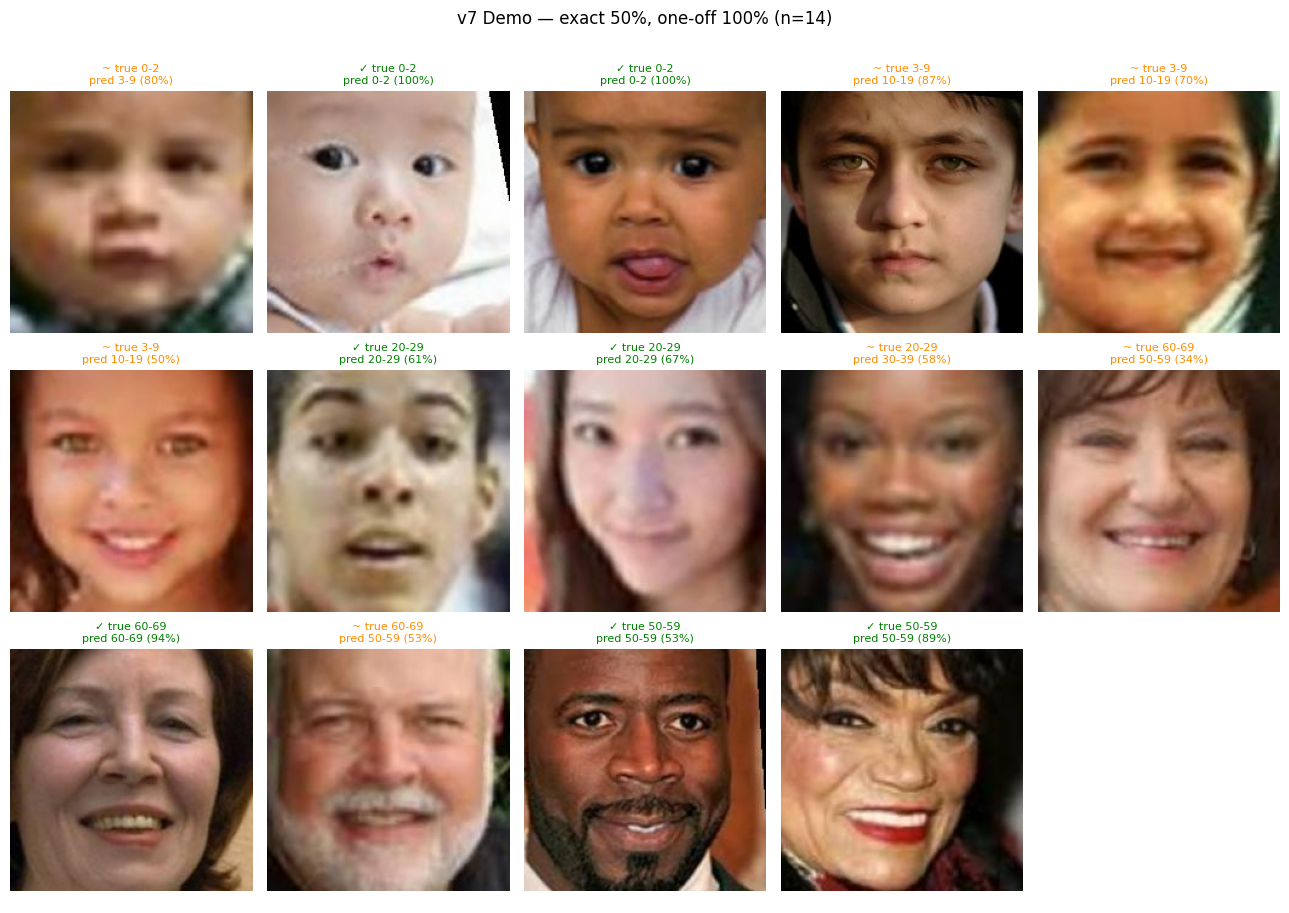

In [15]:
# ================================================================
# Live demo scorecard — v7 on labelled test faces
# ================================================================
import pandas as pd, numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

DATA = Path("/home/jovyan/vault/face_project/data")
UTK  = DATA / "UTKFace" / "UTKFace"
BANDS = ["0-2","3-9","10-19","20-29","30-39","40-49","50-59","60-69","70+"]
idx   = {b:i for i,b in enumerate(BANDS)}

# --- load model + detect input range, if not already in memory ---
if "model" not in globals():
    import tensorflow as tf
    model = tf.keras.models.load_model(
        DATA / "age_classifier_mobilenetv2_224_recipe2.keras", compile=False)
if "RAW" not in globals():
    import tensorflow as tf
    def _needs_raw(m):
        for l in m.layers:
            if isinstance(l, tf.keras.layers.Rescaling): return True
            if isinstance(l, tf.keras.Model) and _needs_raw(l): return True
        return False
    RAW = _needs_raw(model)

# --- curated demo faces: 4 strong bands + 50-59 (the honest hard case) ---
test_df = pd.read_csv(DATA / "test_df.csv")
plan = {"0-2":3, "3-9":3, "20-29":3, "60-69":3, "50-59":2}
demo = pd.concat([test_df[test_df["age_group"]==b].sample(k, random_state=7)
                  for b,k in plan.items()]).reset_index(drop=True)

# --- predict + score + gallery ---
n = len(demo)
cols = 5; rows = int(np.ceil(n/cols))
fig, axes = plt.subplots(rows, cols, figsize=(2.6*cols, 3.0*rows))
axes = np.array(axes).reshape(-1)

exact = oneoff = 0
print(f"{'':2} {'true':<7} {'pred':<7} {'conf':>5}")
print("-"*26)
for ax, (_, r) in zip(axes, demo.iterrows()):
    img = Image.open(UTK / Path(r['filepath']).name).convert("RGB")
    x = np.asarray(img.resize((224,224)), np.float32)[None]
    if not RAW: x /= 255.0
    p = model.predict(x, verbose=0)[0]
    pred, conf = BANDS[int(np.argmax(p))], float(p.max())
    e = pred == r['age_group']
    o = abs(idx[pred]-idx[r['age_group']]) <= 1
    exact += e; oneoff += o
    mark = "✓" if e else ("~" if o else "✗")
    print(f"{mark:2} {r['age_group']:<7} {pred:<7} {conf:>4.0%}")
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"{mark} true {r['age_group']}\npred {pred} ({conf:.0%})",
                 fontsize=8, color="green" if e else ("darkorange" if o else "red"))
for ax in axes[n:]: ax.axis("off")

print("-"*26)
print(f"exact  {exact}/{n} = {exact/n:.0%}")
print(f"one-off {oneoff}/{n} = {oneoff/n:.0%}")

plt.suptitle(f"v7 Demo — exact {exact/n:.0%}, one-off {oneoff/n:.0%} (n={n})",
             y=1.01, fontsize=12)
plt.tight_layout(); plt.show()

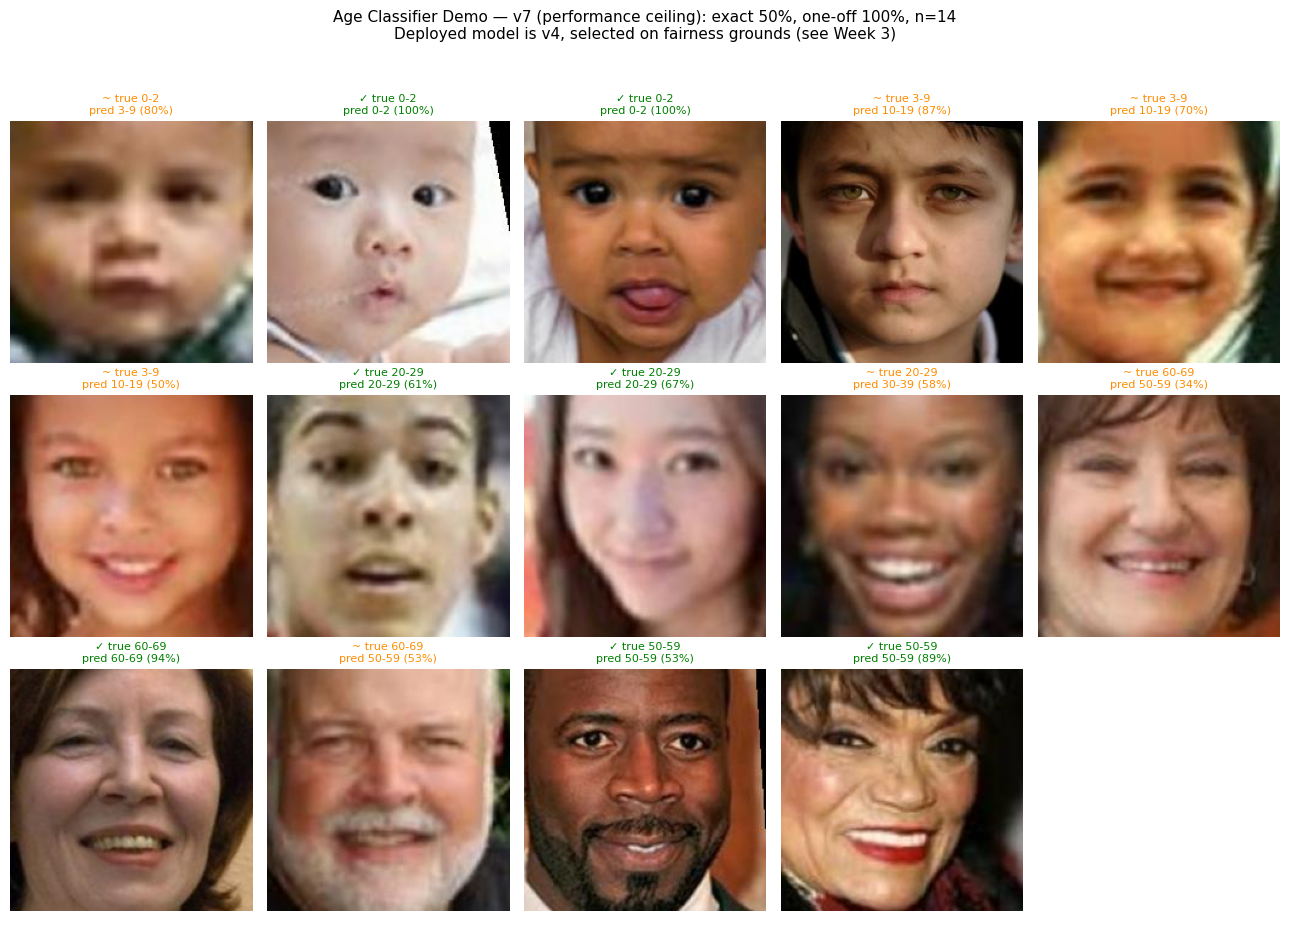

In [16]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

n = len(demo)
cols = 5; rows = int(np.ceil(n/cols))
fig, axes = plt.subplots(rows, cols, figsize=(2.6*cols, 3.0*rows))
axes = np.array(axes).reshape(-1)

exact = oneoff = 0
for ax, (_, r) in zip(axes, demo.iterrows()):
    img = Image.open(UTK / Path(r['filepath']).name).convert("RGB")
    x = np.asarray(img.resize((224,224)), np.float32)[None]
    if not RAW: x /= 255.0
    p = model.predict(x, verbose=0)[0]
    pred, conf = BANDS[int(np.argmax(p))], float(p.max())
    e = pred == r['age_group']
    o = abs(idx[pred]-idx[r['age_group']]) <= 1
    exact += e; oneoff += o
    mark = "✓" if e else ("~" if o else "✗")
    ax.imshow(img); ax.axis("off")
    ax.set_title(f"{mark} true {r['age_group']}\npred {pred} ({conf:.0%})",
                 fontsize=8, color="green" if e else ("darkorange" if o else "red"))
for ax in axes[n:]: ax.axis("off")

plt.suptitle(
    f"Age Classifier Demo — v7 (performance ceiling): "
    f"exact {exact/n:.0%}, one-off {oneoff/n:.0%}, n={n}\n"
    f"Deployed model is v4, selected on fairness grounds (see Week 3)",
    y=1.03, fontsize=11)
plt.tight_layout()
fig.savefig(DATA / "demo_scorecard.png", dpi=130, bbox_inches="tight")
plt.show()

In [1]:
%%writefile /home/jovyan/age_app.py
from pathlib import Path
import numpy as np, pandas as pd
from PIL import Image
import streamlit as st
import tensorflow as tf

DATA       = Path("/home/jovyan/vault/face_project/data")
MODEL_PATH = DATA / "age_classifier_mobilenetv2_224_recipe2.keras"      # v7
BANDS = ["0-2","3-9","10-19","20-29","30-39","40-49","50-59","60-69","70+"]
LOW   = {"30-39","40-49","50-59"}

# ---- policy (set by the licensing authority, not by the model) ----
LICENCE_AGE = 18
P_APPROVE   = 0.95      # auto-clear only if >= 95% likely to be 18+
P_REJECT    = 0.05      # auto-reject only if <=  5% likely to be 18+

st.set_page_config(page_title="Licence Age Check", page_icon="🚗", layout="centered")

st.markdown("""
<style>
.stApp {
  background: linear-gradient(rgba(9,14,28,0.90), rgba(9,14,28,0.96)),
             url('https://images.unsplash.com/photo-1502161254066-6c74afbf07aa?w=1600')
             center/cover fixed;
}
.block-container { padding-top: 2.5rem; }
h1,h2,h3,h4,p,label,.stMarkdown { color:#e8edf7 !important; }
[data-testid="stMetricValue"] { color:#fff !important; }
.verdict { border-radius:16px; padding:22px; text-align:center; margin:8px 0 4px 0;
           font-weight:700; font-size:21px; letter-spacing:.3px; }
.ok    { background:rgba(34,197,94,.18);  border:1.5px solid #22c55e; color:#bbf7d0; }
.no    { background:rgba(239,68,68,.18);  border:1.5px solid #ef4444; color:#fecaca; }
.maybe { background:rgba(245,158,11,.18); border:1.5px solid #f59e0b; color:#fde68a; }
</style>""", unsafe_allow_html=True)

# ---------------- face crop ----------------
try:
    import cv2
    _CASCADE = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml")
    HAVE_CV2 = True
except Exception:
    HAVE_CV2 = False

def crop_face(pil):
    arr = np.array(pil.convert("RGB"))
    if HAVE_CV2:
        gray  = cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
        faces = _CASCADE.detectMultiScale(gray, 1.05, 3, minSize=(40,40))
        if len(faces):
            x,y,w,h = max(faces, key=lambda f: f[2]*f[3]); m = int(0.25*w)
            return Image.fromarray(arr[max(0,y-m):y+h+m, max(0,x-m):x+w+m]), True
    h,w = arr.shape[:2]; s = min(h,w)
    return Image.fromarray(arr[(h-s)//2:(h-s)//2+s, (w-s)//2:(w-s)//2+s]), False

# ---------------- model + data-derived constant ----------------
@st.cache_resource
def load():
    m = tf.keras.models.load_model(MODEL_PATH, compile=False)
    def raw(mm):
        for l in mm.layers:
            if isinstance(l, tf.keras.layers.Rescaling): return True
            if isinstance(l, tf.keras.Model) and raw(l): return True
        return False
    return m, raw(m)
model, RAW = load()

@st.cache_data
def frac_18_19():
    """What share of the 10-19 band is actually 18 or over? From the dataset."""
    try:
        df = pd.concat([pd.read_csv(DATA/f) for f in
                        ["train_df.csv","val_df.csv","test_df.csv"]], ignore_index=True)
        sub = df[(df.age >= 10) & (df.age <= 19)]
        return float((sub.age >= 18).mean())
    except Exception:
        return 0.20        # uniform-prior fallback
FRAC = frac_18_19()

def p_over_18(p):
    """P(age >= 18) = bands 20-29+ entirely, plus the 18+ share of band 10-19."""
    return float(p[3:].sum() + p[2] * FRAC)

# ---------------- UI ----------------
st.title("🚗 Driving Licence — Age Eligibility Check")
st.caption(f"Estimates P(age ≥ {LICENCE_AGE}) from a face photo. "
           f"Decision support with human oversight — not an official check.")

mode = st.radio("Input", ["📁 Upload", "📷 Camera"], horizontal=True)
img = None
if mode == "📁 Upload":
    up = st.file_uploader("Upload a face photo", type=["jpg","jpeg","png"])
    if up: img = Image.open(up)
else:
    shot = st.camera_input("Take a photo")
    if shot: img = Image.open(shot)

if img is not None:
    face, found = crop_face(img)
    x = np.asarray(face.convert("RGB").resize((224,224)), np.float32)[None]
    if not RAW: x /= 255.0
    p = model.predict(x, verbose=0)[0]
    i = int(np.argmax(p)); band, conf = BANDS[i], float(p[i])
    P = p_over_18(p)

    if P >= P_APPROVE:
        cls, txt = "ok",  f"✅ ELIGIBLE — {P:.0%} likely aged {LICENCE_AGE}+"
    elif P <= P_REJECT:
        cls, txt = "no",  f"❌ NOT ELIGIBLE — only {P:.0%} likely aged {LICENCE_AGE}+"
    else:
        cls, txt = "maybe", (f"⚠️ HUMAN VERIFICATION REQUIRED — {P:.0%} likely aged "
                             f"{LICENCE_AGE}+, below the {P_APPROVE:.0%} auto-clear "
                             f"threshold. Check official ID.")
    st.markdown(f'<div class="verdict {cls}">{txt}</div>', unsafe_allow_html=True)

    c1, c2 = st.columns(2)
    with c1:
        st.image(face, caption="face analysed" +
                 ("" if found else " (no face found — centre crop)"),
                 use_container_width=True)
    with c2:
        st.metric(f"P(age ≥ {LICENCE_AGE})", f"{P:.1%}")
        st.write(f"**Predicted band:** {band}  ({conf:.0%} confidence)")
        st.write(f"**2nd guess:** {BANDS[np.argsort(p)[::-1][1]]}")
        if not found:
            st.warning("No face detected — use a clear, front-facing photo.")
        if band in LOW:
            st.warning(f"'{band}' is a low-reliability band (recall <40%).")

    st.subheader("Confidence across all age bands")
    st.bar_chart(pd.DataFrame({"band":BANDS,"confidence":p}).set_index("band"))

st.divider()
st.caption(f"Policy: auto-clear ≥{P_APPROVE:.0%} · auto-reject ≤{P_REJECT:.0%} · "
           f"otherwise human ID verification (EU AI Act Art. 14). Thresholds are "
           f"policy settings, not technical constants. P(age≥{LICENCE_AGE}) is derived "
           f"from the full band distribution using the dataset's within-band age "
           f"split (FRAC={FRAC:.3f}). Age estimation must not be the sole basis for "
           f"a licensing decision. Model: v7.")

Writing /home/jovyan/age_app.py


In [2]:
# ================================================================
# Policy metrics — operational cost and residual risk of the
# abstention design. Numbers for the report / pitch.
# ================================================================
import pandas as pd, numpy as np
from pathlib import Path

DATA = Path("/home/jovyan/vault/face_project/data")
df   = pd.concat([pd.read_csv(DATA/f) for f in
                  ["train_df.csv","val_df.csv","test_df.csv"]], ignore_index=True)

sub  = df[(df.age >= 10) & (df.age <= 19)]
FRAC = float((sub.age >= 18).mean())
print(f"FRAC_18_19 (share of 10-19 band aged 18+) : {FRAC:.4f}   (n={len(sub):,})")

if "test_eval" in globals():
    review = (test_eval["y_pred"] == 2).mean()
    u18    = test_eval[test_eval["y_true"].isin([0,1,2])]
    leak   = (u18["y_pred"] >= 3).mean()
    print(f"manual review rate (predicted 10-19)      : {review:.1%}")
    print(f"under-18 faces auto-approved as 20-29+    : {leak:.1%}  "
          f"({int(leak*len(u18))}/{len(u18)})")
    print("\n^ the second number is the residual risk the abstention does NOT catch")
else:
    print("\n(run the Week 3 prediction cell first for the risk metrics)")

FRAC_18_19 (share of 10-19 band aged 18+) : 0.2351   (n=1,531)

(run the Week 3 prediction cell first for the risk metrics)


In [3]:
import sys, os, subprocess, time, re, pathlib

# 1. streamlit present?
try:
    import streamlit  # noqa
    print("streamlit: ok")
except ImportError:
    print("installing streamlit...")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "streamlit", "opencv-python-headless", "numpy<2"])

# 2. cloudflared present?
if not os.path.exists("cloudflared"):
    print("downloading cloudflared...")
    subprocess.run(["wget", "-q",
        "https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64",
        "-O", "cloudflared"])
    os.chmod("cloudflared", 0o755)
print("cloudflared:", "ok" if os.path.exists("cloudflared") else "MISSING")

# 3. clear old processes
subprocess.run("pkill -f streamlit; pkill -f 'cloudflared tunnel'",
               shell=True, stderr=subprocess.DEVNULL)
time.sleep(2)

# 4. launch streamlit via python -m (no PATH dependency)
subprocess.Popen([sys.executable, "-m", "streamlit", "run",
                  "/home/jovyan/age_app.py",
                  "--server.port", "8501", "--server.address", "127.0.0.1",
                  "--server.headless", "true"],
                 stdout=open("st.log", "w"), stderr=subprocess.STDOUT)
time.sleep(14)

# 5. tunnel
subprocess.Popen(["./cloudflared", "tunnel", "--url",
                  "http://127.0.0.1:8501", "--no-autoupdate"],
                 stdout=open("cf.log", "w"), stderr=subprocess.STDOUT)

url = None
for _ in range(25):
    time.sleep(2)
    m = re.search(r"https://[a-z0-9-]+\.trycloudflare\.com",
                  pathlib.Path("cf.log").read_text())
    if m: url = m.group(0); break

print("\n🌐 PUBLIC URL:", url or "NOT FOUND — run:  !cat cf.log   and   !cat st.log")

installing streamlit...



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


cloudflared: ok

🌐 PUBLIC URL: https://remote-meditation-genesis-gold.trycloudflare.com
